# Plotting Shannon Entropy

## Imports

In [1]:
list_of_packages <- c("ggplot2", "dplyr", "arrow")

for (package in list_of_packages) {
    suppressPackageStartupMessages(
        suppressWarnings(
            library(
                package,
                character.only = TRUE,
                quietly = TRUE,
                warn.conflicts = FALSE
            )
        )
    )
}

In [2]:
# Get the current working directory and find Git root
find_git_root <- function() {
    # Get current working directory
    cwd <- getwd()

    # Check if current directory has .git
    if (dir.exists(file.path(cwd, ".git"))) {
        return(cwd)
    }

    # If not, search parent directories
    current_path <- cwd
    while (dirname(current_path) != current_path) {  # While not at root
        parent_path <- dirname(current_path)
        if (dir.exists(file.path(parent_path, ".git"))) {
            return(parent_path)
        }
        current_path <- parent_path
    }

    # If no Git root found, stop with error
    stop("No Git root directory found.")
}

# Find the Git root directory
root_dir <- find_git_root()
cat("Git root directory:", root_dir, "\n")

Git root directory: /Users/kaylorhuang/Documents/GitHub_Repos/Kaylor---NF1_organoid_profile_analysis 


In [3]:
entropy_dir <- file.path(root_dir, "1.EDA", "results", "entropy")

# Normal profiles
organoid_normal_2d <- arrow::read_parquet(file.path(entropy_dir, "2D_organoid_entropy.parquet"))
organoid_normal_3d <- arrow::read_parquet(file.path(entropy_dir, "3D_organoid_entropy.parquet"))
sc_normal_2d       <- arrow::read_parquet(file.path(entropy_dir, "2D_sc_entropy.parquet"))
sc_normal_3d       <- arrow::read_parquet(file.path(entropy_dir, "3D_sc_entropy.parquet"))

# Feature-selected profiles
organoid_fs_2d <- arrow::read_parquet(file.path(entropy_dir, "2D_organoid_fs_entropy.parquet"))
organoid_fs_3d <- arrow::read_parquet(file.path(entropy_dir, "3D_organoid_fs_entropy.parquet"))
sc_fs_2d       <- arrow::read_parquet(file.path(entropy_dir, "2D_sc_fs_entropy.parquet"))
sc_fs_3d       <- arrow::read_parquet(file.path(entropy_dir, "3D_sc_fs_entropy.parquet"))

# Aggregated profiles
organoid_agg_2d <- arrow::read_parquet(file.path(entropy_dir, "2D_organoid_agg_entropy.parquet"))
organoid_agg_3d <- arrow::read_parquet(file.path(entropy_dir, "3D_organoid_agg_entropy.parquet"))
sc_agg_2d       <- arrow::read_parquet(file.path(entropy_dir, "2D_sc_agg_entropy.parquet"))
sc_agg_3d       <- arrow::read_parquet(file.path(entropy_dir, "3D_sc_agg_entropy.parquet"))

# Combine 2D + 3D and set ordered factor
fix_modality <- function(df) {
    df$modality <- factor(df$modality, levels = c("2D", "3D"))
    df
}

organoid_normal_combined <- fix_modality(rbind(organoid_normal_2d, organoid_normal_3d))
sc_normal_combined       <- fix_modality(rbind(sc_normal_2d,       sc_normal_3d))
organoid_fs_combined     <- fix_modality(rbind(organoid_fs_2d,     organoid_fs_3d))
sc_fs_combined           <- fix_modality(rbind(sc_fs_2d,           sc_fs_3d))
organoid_agg_combined    <- fix_modality(rbind(organoid_agg_2d,    organoid_agg_3d))
sc_agg_combined          <- fix_modality(rbind(sc_agg_2d,          sc_agg_3d))

In [4]:
figures_dir <- file.path(root_dir, "1.EDA", "figures", "entropy")
dir.create(figures_dir, recursive = TRUE, showWarnings = FALSE)

In [5]:
entropy_theme <- theme(
    plot.title   = element_text(hjust = 0.5, size = 14),
    axis.title.x = element_text(size = 16),
    axis.title.y = element_text(size = 16),
    axis.text.x  = element_text(size = 14),
    axis.text.y  = element_text(size = 14),
    legend.title = element_text(size = 14),
    legend.text  = element_text(size = 12)
)

modality_colors <- c("2D" = "#4e79a7", "3D" = "#f28e2b")

make_entropy_plot <- function(df, title) {
    ggplot(df, aes(x = modality, y = entropy, fill = modality)) +
        geom_violin(alpha = 0.6, trim = FALSE) +
        geom_boxplot(width = 0.15, alpha = 0.85, outlier.size = 0.5, outlier.alpha = 0.4) +
        scale_fill_manual(values = modality_colors) +
        labs(
            title = title,
            x     = "Modality",
            y     = "Shannon Entropy (bits)",
            fill  = "Modality"
        ) +
        theme_bw() +
        entropy_theme
}

## Plotting violin plots for normal, fs, and agg datasets

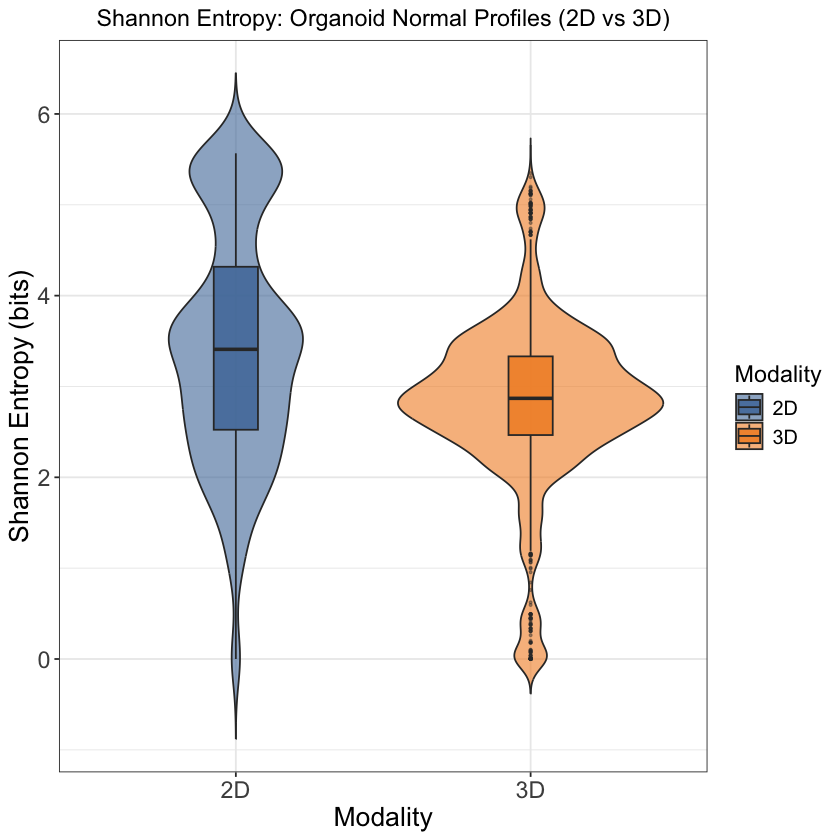

In [6]:
organoid_normal_plot <- make_entropy_plot(
    organoid_normal_combined,
    "Shannon Entropy: Organoid Normal Profiles (2D vs 3D)"
)
print(organoid_normal_plot)

ggsave(
    filename = file.path(figures_dir, "organoid_normal_entropy_2D_vs_3D.png"),
    plot     = organoid_normal_plot,
    width    = 6,
    height   = 6,
    dpi      = 600,
    units    = "in"
)

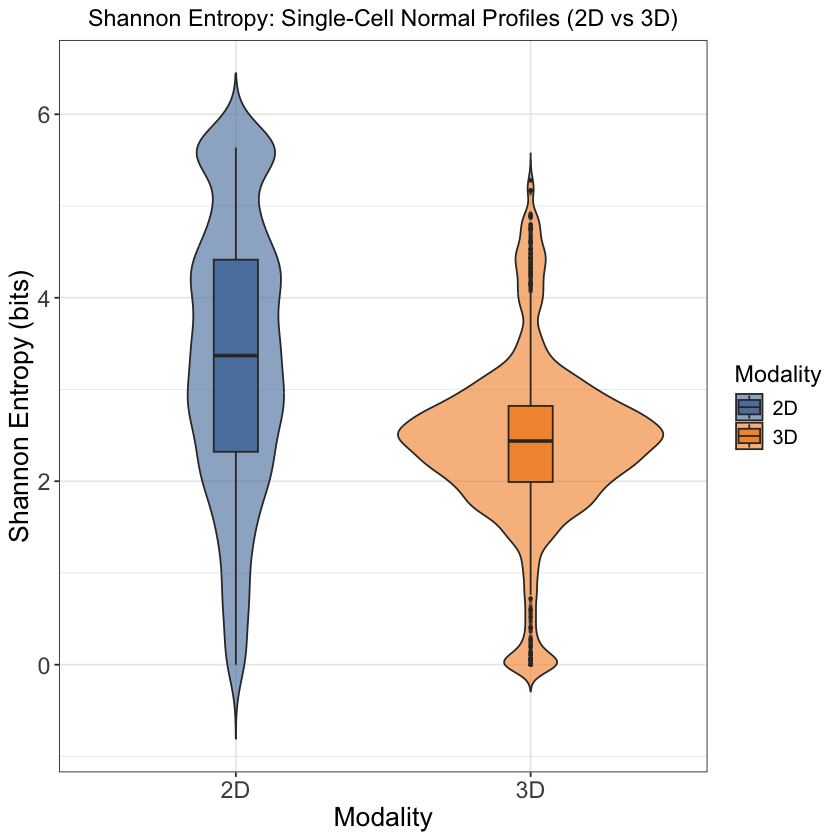

In [7]:
sc_normal_plot <- make_entropy_plot(
    sc_normal_combined,
    "Shannon Entropy: Single-Cell Normal Profiles (2D vs 3D)"
)
print(sc_normal_plot)

ggsave(
    filename = file.path(figures_dir, "sc_normal_entropy_2D_vs_3D.png"),
    plot     = sc_normal_plot,
    width    = 6,
    height   = 6,
    dpi      = 600,
    units    = "in"
)

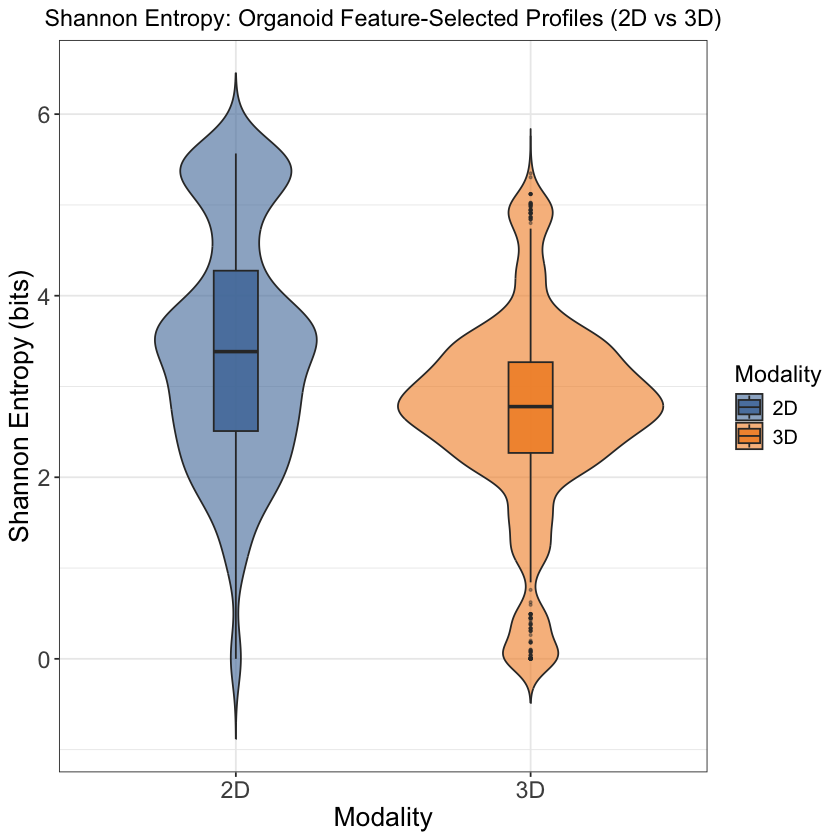

In [8]:
organoid_fs_plot <- make_entropy_plot(
    organoid_fs_combined,
    "Shannon Entropy: Organoid Feature-Selected Profiles (2D vs 3D)"
)
print(organoid_fs_plot)

ggsave(
    filename = file.path(figures_dir, "organoid_fs_entropy_2D_vs_3D.png"),
    plot     = organoid_fs_plot,
    width    = 6,
    height   = 6,
    dpi      = 600,
    units    = "in"
)

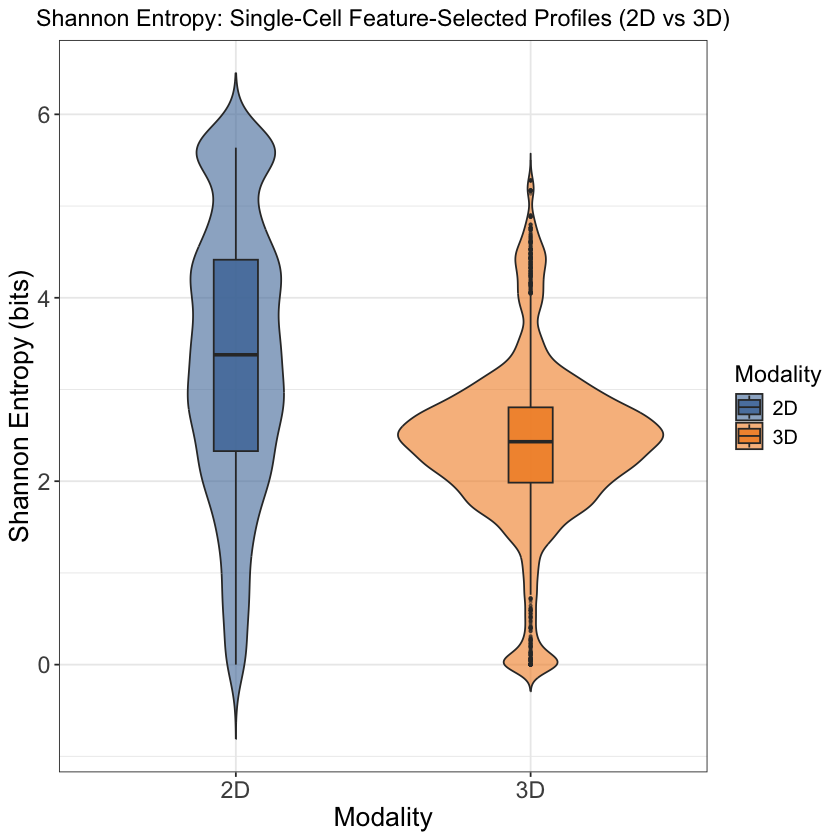

In [9]:
sc_fs_plot <- make_entropy_plot(
    sc_fs_combined,
    "Shannon Entropy: Single-Cell Feature-Selected Profiles (2D vs 3D)"
)
print(sc_fs_plot)

ggsave(
    filename = file.path(figures_dir, "sc_fs_entropy_2D_vs_3D.png"),
    plot     = sc_fs_plot,
    width    = 6,
    height   = 6,
    dpi      = 600,
    units    = "in"
)

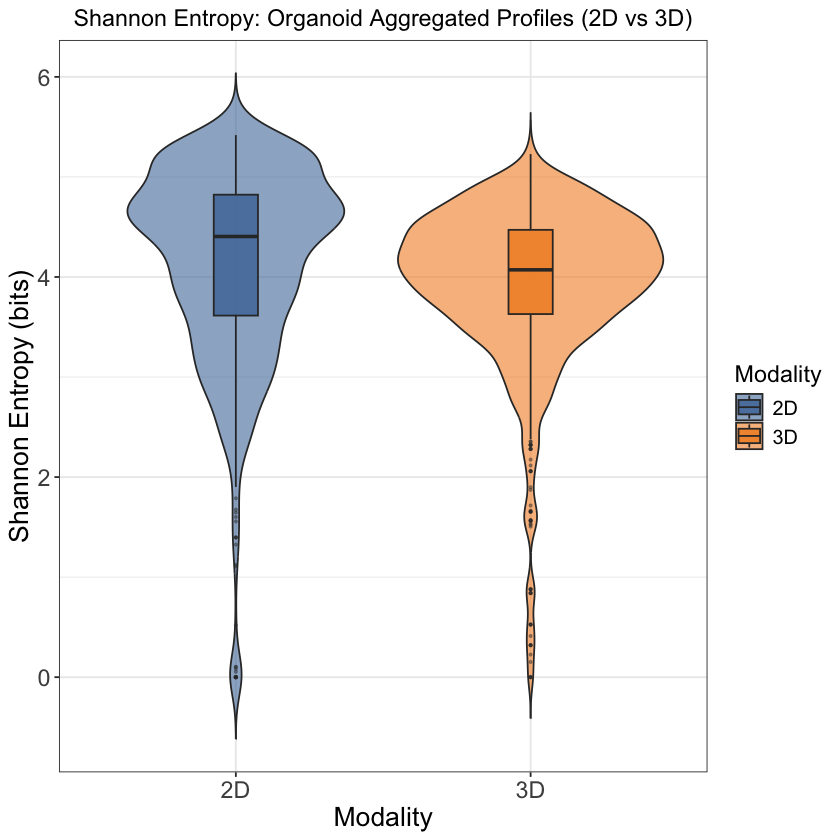

In [10]:
organoid_agg_plot <- make_entropy_plot(
    organoid_agg_combined,
    "Shannon Entropy: Organoid Aggregated Profiles (2D vs 3D)"
)
print(organoid_agg_plot)

ggsave(
    filename = file.path(figures_dir, "organoid_agg_entropy_2D_vs_3D.png"),
    plot     = organoid_agg_plot,
    width    = 6,
    height   = 6,
    dpi      = 600,
    units    = "in"
)

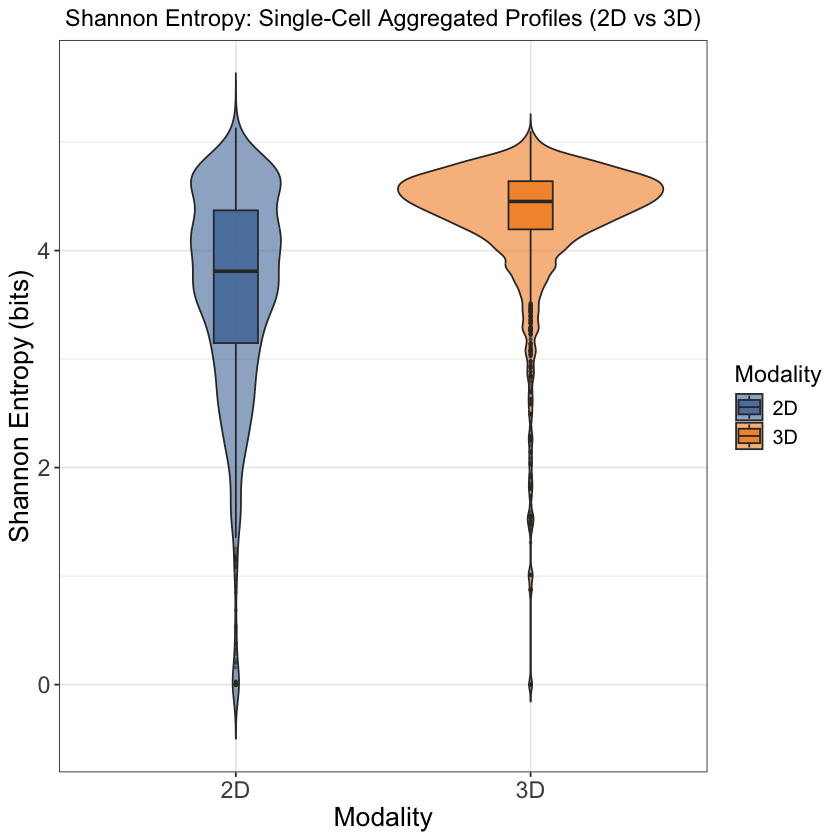

In [11]:
sc_agg_plot <- make_entropy_plot(
    sc_agg_combined,
    "Shannon Entropy: Single-Cell Aggregated Profiles (2D vs 3D)"
)
print(sc_agg_plot)

ggsave(
    filename = file.path(figures_dir, "sc_agg_entropy_2D_vs_3D.png"),
    plot     = sc_agg_plot,
    width    = 6,
    height   = 6,
    dpi      = 600,
    units    = "in"
)